<a href="https://colab.research.google.com/github/chitrasavithri176-cmyk/python-ex/blob/main/credit_card_fraud_detection_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

df = pd.read_csv('/content/credit_card_fraud_2026.csv')
display(df.head())

,transaction_id,amount_usd,merchant_category,card_type,auth_method,channel,device_type,is_foreign_transaction,hours_since_last_txn,txn_count_last_24h,...,ip_country_mismatch,billing_shipping_mismatch,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,is_ai_generated_scam_attempt,merchant_risk_score,prior_disputes,is_fraud
0,1,42.86,Restaurants,Visa,OTP,Online,Android Phone,False,13.54,2,...,False,False,0,0.1,18,3,False,42.3,0,0
1,2,4.75,Online Retail,Mastercard,3D Secure,Online,Android Phone,False,0.71,2,...,False,False,0,25.8,12,4,False,28.3,0,0
2,3,77.18,Groceries,Mastercard,3D Secure,Online,Mac,False,0.35,5,...,False,True,0,42.3,5,0,False,24.7,1,0
3,4,1.69,Streaming,Visa,No Authentication,POS,Android Phone,False,3.42,6,...,False,False,0,28.9,22,6,False,56.2,1,0
4,5,261.68,Travel,Visa,3D Secure,In-App,iPhone,False,2.43,2,...,False,False,0,3.9,2,4,False,32.7,0,0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   transaction_id                20000 non-null  int64  
 1   amount_usd                    20000 non-null  float64
 2   merchant_category             20000 non-null  object 
 3   card_type                     20000 non-null  object 
 4   auth_method                   20000 non-null  object 
 5   channel                       20000 non-null  object 
 6   device_type                   20000 non-null  object 
 7   is_foreign_transaction        20000 non-null  bool   
 8   hours_since_last_txn          20000 non-null  float64
 9   txn_count_last_24h            20000 non-null  int64  
 10  distance_from_home_km         20000 non-null  float64
 11  card_age_months               20000 non-null  int64  
 12  customer_age                  20000 non-null  int64  
 13  a

In [3]:
display(df.describe())

,transaction_id,amount_usd,hours_since_last_txn,txn_count_last_24h,distance_from_home_km,card_age_months,customer_age,account_balance_usd,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,merchant_risk_score,prior_disputes,is_fraud
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,10000.500000,132.424597,8.950827,3.191650,22.139525,46.937550,49.669400,3316.662598,0.181300,19.807735,11.533650,2.998750,37.400390,0.281250,0.016950
std,5773.647028,256.963666,8.838745,1.779544,22.120960,6.768577,18.494032,4350.720948,0.422302,12.366301,6.925335,2.004956,17.061415,0.529209,0.129087
min,1.000000,1.000000,0.010000,0.000000,0.000000,22.000000,18.000000,52.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5000.750000,26.235000,2.590000,2.000000,6.337500,42.000000,34.000000,1019.140000,0.000000,10.700000,6.000000,1.000000,25.600000,0.000000,0.000000
50%,10000.500000,57.510000,6.210000,3.000000,15.505000,47.000000,50.000000,2007.685000,0.000000,18.800000,12.000000,3.000000,35.700000,0.000000,0.000000
75%,15000.250000,131.752500,12.432500,4.000000,30.820000,51.000000,66.000000,3944.120000,0.000000,27.600000,18.000000,5.000000,47.300000,0.000000,0.000000
max,20000.000000,6872.690000,87.050000,12.000000,216.190000,74.000000,81.000000,127125.860000,3.000000,74.400000,23.000000,6.000000,100.000000,4.000000,1.000000


In [4]:
for column in df.select_dtypes(include='object').columns:
    print(f"Column: {column}")
    print(df[column].value_counts())
    print("\n")

Column: merchant_category
merchant_category
Online Retail      3416
Groceries          3242
Restaurants        2534
Electronics        2032
Fuel               1565
Travel             1420
Utilities          1330
Healthcare         1237
Gaming             1036
Streaming          1010
Gift Cards          617
Crypto Exchange     561
Name: count, dtype: int64


Column: card_type
card_type
Visa          8417
Mastercard    6629
Amex          2135
RuPay         1796
Discover      1023
Name: count, dtype: int64


Column: auth_method
auth_method
3D Secure            5554
OTP                  4792
PIN                  4173
Biometric            3093
No Authentication    2388
Name: count, dtype: int64


Column: channel
channel
Online         6810
POS            5191
Contactless    3400
In-App         3225
ATM            1374
Name: count, dtype: int64


Column: device_type
device_type
Android Phone    5503
iPhone           4179
POS Terminal     3162
Windows PC       2623
Mac              1359
Table

In [5]:
df['is_fraud'].value_counts()

,count
is_fraud,
0,19661
1,339


In [6]:
y = df['is_fraud']
X = df.drop('is_fraud', axis=1)

# Convert boolean columns to integers (0 or 1)
for col in X.select_dtypes(include='bool').columns:
    X[col] = X[col].astype(int)

# Identify categorical columns for one-hot encoding
categorical_cols = X.select_dtypes(include='object').columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

display(X.head())

,transaction_id,amount_usd,is_foreign_transaction,hours_since_last_txn,txn_count_last_24h,distance_from_home_km,card_age_months,customer_age,account_balance_usd,is_new_merchant,...,channel_In-App,channel_Online,channel_POS,device_type_Android Phone,device_type_Mac,device_type_POS Terminal,device_type_Smart Watch,device_type_Tablet,device_type_Windows PC,device_type_iPhone
0,1,42.86,0,13.54,2,22.35,39,25,1080.71,0,...,False,True,False,True,False,False,False,False,False,False
1,2,4.75,0,0.71,2,35.28,47,33,4463.72,1,...,False,True,False,True,False,False,False,False,False,False
2,3,77.18,0,0.35,5,9.82,51,59,366.25,0,...,False,True,False,False,True,False,False,False,False,False
3,4,1.69,0,3.42,6,19.72,48,28,1345.29,1,...,False,False,True,True,False,False,False,False,False,False
4,5,261.68,0,2.43,2,17.68,43,36,4192.59,0,...,True,False,False,False,False,False,False,False,False,True


/tmp/ipykernel_544/535139303.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='viridis')


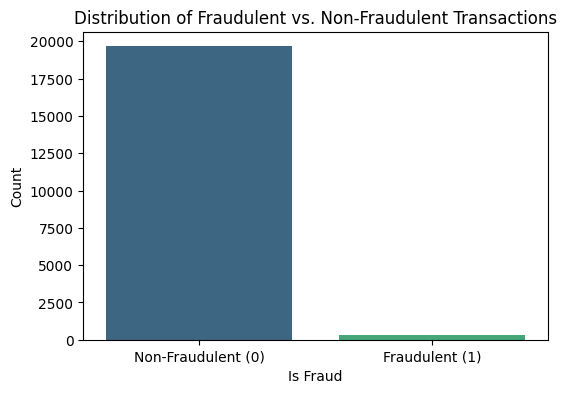

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x=y, palette='viridis')
plt.title('Distribution of Fraudulent vs. Non-Fraudulent Transactions')
plt.xlabel('Is Fraud')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Non-Fraudulent (0)', 'Fraudulent (1)'])
plt.show()

In [8]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Identify numerical columns for scaling
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

# Initialize StandardScaler
scaler = StandardScaler()

# Scale numerical columns
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print(f"Shape of X after SMOTE: {X_resampled.shape}")
print(f"Shape of y after SMOTE: {y_resampled.shape}")
print("Distribution of 'is_fraud' after SMOTE:")
print(y_resampled.value_counts())

Shape of X after SMOTE: (39322, 50)
Shape of y after SMOTE: (39322,)
Distribution of 'is_fraud' after SMOTE:
is_fraud
0    19661
1    19661
Name: count, dtype: int64


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42, stratify=y_resampled)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (27525, 50)
X_test shape: (11797, 50)
y_train shape: (27525,)
y_test shape: (11797,)


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Initialize and train the Logistic Regression model
model = LogisticRegression(random_state=42, solver='liblinear') # Using 'liblinear' solver for smaller datasets
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1] # Probabilities for the positive class (fraud)

# Evaluate the model
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nROC AUC Score:")
print(roc_auc_score(y_test, y_prob))

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      5899
           1       0.99      0.98      0.98      5898

    accuracy                           0.98     11797
   macro avg       0.98      0.98      0.98     11797
weighted avg       0.98      0.98      0.98     11797


Confusion Matrix:
[[5827   72]
 [ 122 5776]]

ROC AUC Score:
0.9977989096553599


In [11]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0] # For binary classification, use the first row of coef_
})

feature_importance['Absolute_Coefficient'] = abs(feature_importance['Coefficient'])
feature_importance = feature_importance.sort_values(by='Absolute_Coefficient', ascending=False)

print("Top 10 Most Important Features:")
display(feature_importance.head(10))

Top 10 Most Important Features:


,Feature,Coefficient,Absolute_Coefficient
30,merchant_category_Utilities,4.447783,4.447783
24,merchant_category_Groceries,3.976342,3.976342
28,merchant_category_Streaming,3.893786,3.893786
25,merchant_category_Healthcare,3.827586,3.827586
21,merchant_category_Fuel,3.758475,3.758475
47,device_type_Tablet,3.739219,3.739219
26,merchant_category_Online Retail,3.669328,3.669328
27,merchant_category_Restaurants,3.554405,3.554405
22,merchant_category_Gaming,3.486893,3.486893
43,device_type_Android Phone,3.433551,3.433551


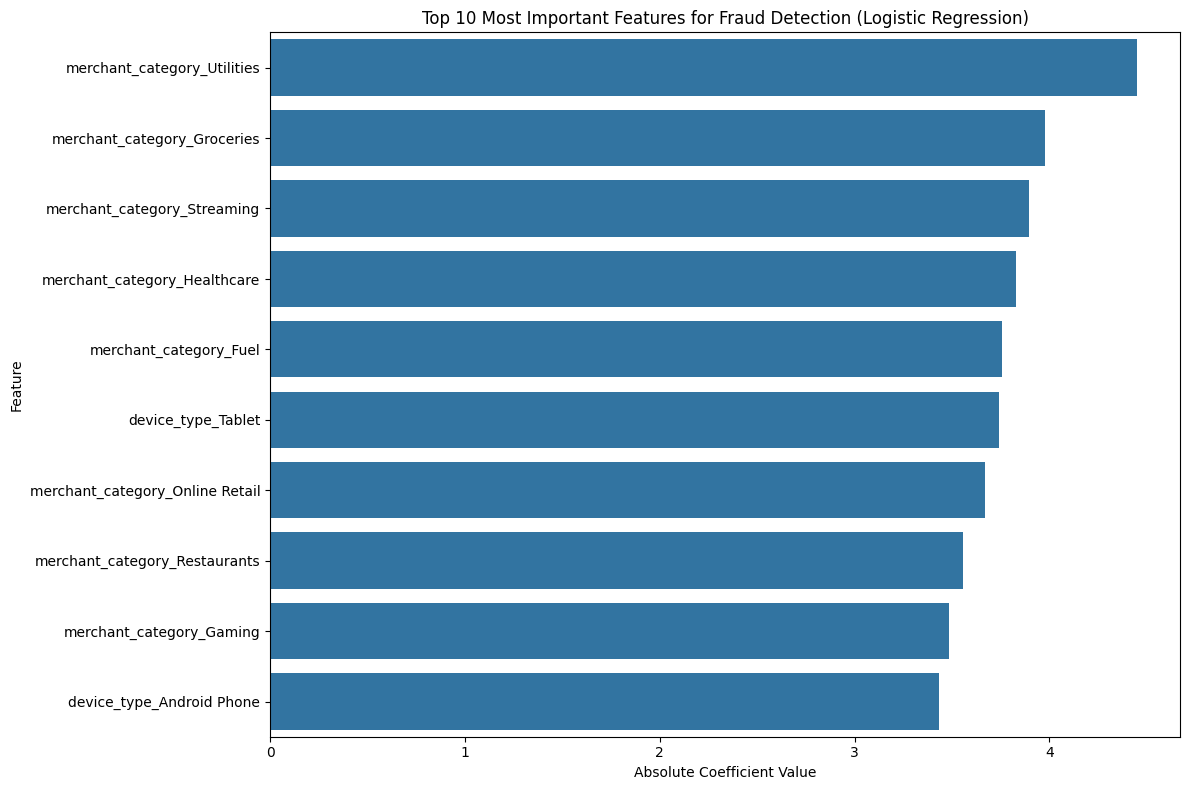

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize feature importance
plt.figure(figsize=(12, 8))
sns.barplot(x='Absolute_Coefficient', y='Feature', data=feature_importance.head(10))
plt.title('Top 10 Most Important Features for Fraud Detection (Logistic Regression)')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

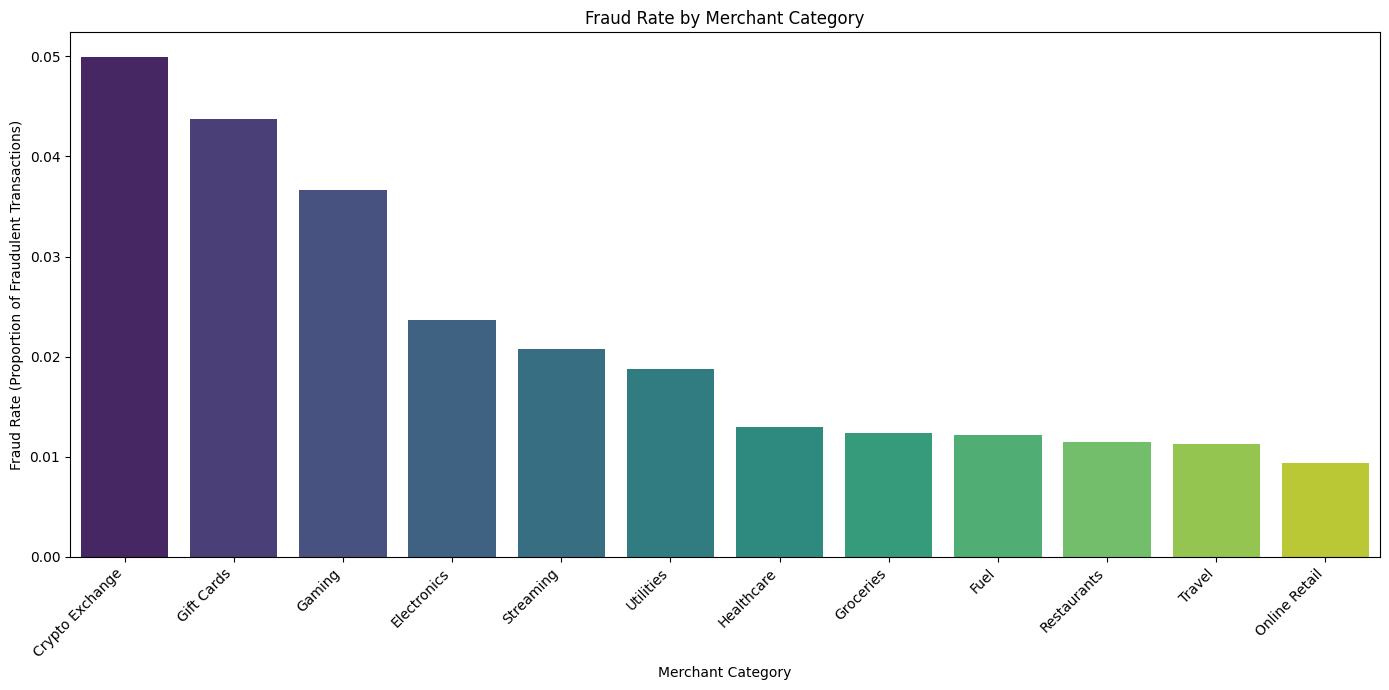

In [14]:
fraud_by_merchant_category = df.groupby('merchant_category')['is_fraud'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(14, 7))
sns.barplot(x='merchant_category', y='is_fraud', data=fraud_by_merchant_category, palette='viridis', hue='merchant_category', legend=False)
plt.title('Fraud Rate by Merchant Category')
plt.xlabel('Merchant Category')
plt.ylabel('Fraud Rate (Proportion of Fraudulent Transactions)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()